# 03. Agent 구현

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from bandit import Bandit
plt.rcParams['font.family'] = 'AppleGothic'   # macOS

plt.rcParams['axes.unicode_minus'] = False

rng = np.random.default_rng(22)

## 표본평균으로 행동 가치 추정하기

환경의 실제 행동 가치 $q(a)$를 모르는 에이전트는 관측한 보상의 평균으로 그 값을 추정한다. 먼저 **같은 슬롯머신 하나를 계속 플레이하는 경우**를 생각해 보자. 여기서는 슬롯머신을 나타내는 $a$를 생략한다.

- $R_i$: 해당 머신을 $i$번째 플레이했을 때 받은 보상
- $Q_n$: 해당 머신을 $n$번 플레이한 뒤 계산한 추정 가치, 즉 보상의 표본평균
- $n$: 해당 머신에서 보상을 관측한 횟수

### 1. 보상에 대해 표본평균 구하기

$n$번 관측한 보상의 평균은 다음과 같다.

$$
Q_n = \frac{R_1 + R_2 + \cdots + R_n}{n}
$$

코드로는 보상을 리스트에 저장한 뒤 평균을 계산할 수 있다.

```python
rewards.append(reward)
Q = sum(rewards) / n
```

이 방식은 이해하기 쉽지만, 매번 지금까지의 보상을 모두 더해야 한다. $n$번째 갱신에 필요한 덧셈의 양과 저장할 보상의 수가 $n$에 따라 증가한다.

### 2. 직전 추정치를 이용한 표본 평균 구하기


$n-1$번째 시점의 행동 가치 추정치 $Q_{n-1}$


$$
Q_{n-1} = \frac{R_1 + R_2 + \cdots + R_{n-1}}{n-1}
$$

양변에 $n-1$을 곱하면, 

$$
R_1 + R_2 + \cdots + R_{n-1} = (n-1)Q_{n-1}
$$

이를 $Q_n$의 식에 대입하면,

$$
\begin{aligned}
Q_n
&= \frac{R_1 + R_2 + \cdots + R_n}{n} \\
&= \frac{1}{n}\left((R_1 + \cdots + R_{n-1}) + R_n\right) \\
&= \frac{1}{n}\left((n-1)Q_{n-1} + R_n\right) \\
&= \left(1-\frac{1}{n}\right)Q_{n-1}+\frac{1}{n}R_n \\
&= Q_{n-1}+\frac{1}{n}\left(R_n-Q_{n-1}\right).
\end{aligned}
$$


### 3. 증분 구현 **(incremental implimentation)** 

$$
\underbrace{Q_n}_{\text{새 추정치}}
=
\underbrace{Q_{n-1}}_{\text{이전 추정치}}
+
\underbrace{\frac{1}{n}}_{\text{학습률}}
\underbrace{\left(R_n-Q_{n-1}\right)}_{\text{새 보상과 이전 추정치의 차이}}
$$



In [40]:
# 슬롯 머신 수 지정 
K = 10

# 인스턴스 만들기
bandit = Bandit(K)

# 관심 슬롯 머신 지정 
target_arm = 0
# 시도 횟수 지정 
N = 10000
# 값 초기화 
Q = 0

rewards = []
Qs = []
# N번 시도 
for n in  range ( 1 , N+ 1 ):
     # arm번째 머신 플레이
    reward = bandit.play(target_arm)
    rewards.append(reward)
    # # n 번째 시점의 행동가치 추정치 업데이트 
    Q = Q + (reward - Q) / n
    Qs.append(Q)

rewards = np.array(rewards)
Qs = np.array(Qs)
    

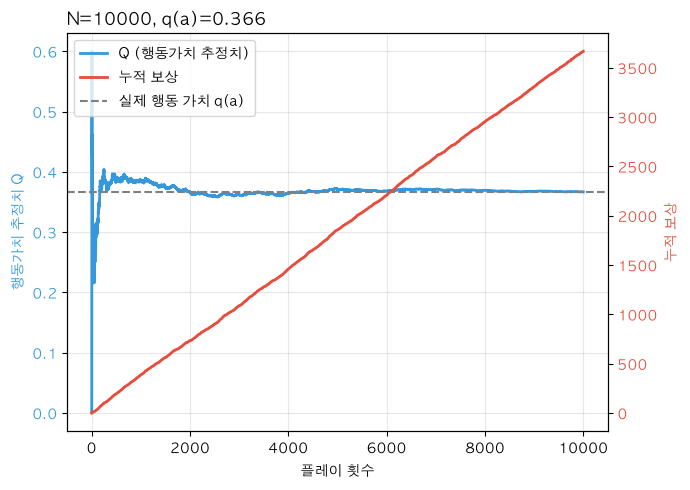

In [41]:
fig, ax_left = plt.subplots(figsize=(7, 5))
ax_right = ax_left.twinx()

x = np.arange(1, N + 1)

line1, = ax_left.plot(
    x, Qs,
    label="Q (행동가치 추정치)", color="#3498db", linewidth=2
)
line2, = ax_right.plot(
    x, np.cumsum(rewards),
    label="누적 보상", color="#e74c3c", linewidth=2
)

ax_left.set_xlabel("플레이 횟수")
ax_left.set_ylabel("행동가치 추정치 Q", color="#3498db")
ax_right.set_ylabel("누적 보상", color="#e74c3c")

ax_left.tick_params(axis="y", labelcolor="#3498db")
ax_right.tick_params(axis="y", labelcolor="#e74c3c")

ax_left.legend(handles=[line1, line2], loc="upper left")
ax_left.grid(alpha=0.3)
ax_left.set_title('N=' + str (N) + ', q(a)='+str(np.round(bandit.rates[target_arm], 3 )),fontsize=12, fontweight='bold', loc='left')

line3 = ax_left.axhline(
    bandit.rates[target_arm],
    color="gray", linestyle="--", label="실제 행동 가치 q(a)"
)
ax_left.legend(handles=[line1, line2, line3], loc="upper left")
plt.tight_layout()
plt.show()


## 플레이어 정책

플레이어(에이전트)는 플레이 경험으로 각 슬롯머신의 행동 가치를 추정한다. 이제 이 추정치를 이용해 **다음에 어떤 슬롯머신을 선택할지** 결정해야 한다. 행동을 선택하는 규칙을 **정책(policy)**이라고 한다.


### 1. 탐욕 정책의 한계와 탐험



In [42]:
K = 10
bandit = Bandit()
# 각 슬롯 머신의 확률 확인 
print ( 'p =' , np.round(bandit.rates, 2 ))

# 시도 횟수 지정 
N = 10

# 값 초기화
Qs = np.zeros(K)
ns = np.zeros(K)

# N번 시도 
for n in  range ( 1 , N+ 1 ):
     # 플레이할 머신 번호를 무작위로 결정 
    action = np.random.randint( 0 , K)
    
    # action번째 머신 플레이
    reward = bandit.play(action)
    
    # action번째 플레이 횟수를 카운트업 
    ns[action] += 1 
    Qs[action] += (reward - Qs[action]) / ns[action]

p = [0.37 0.2  0.09 0.65 0.46 0.99 0.85 0.84 0.05 0.56]



### 2. 탐욕(Greedy) 정책

경험을 통해 얻은 $Q(a)$가 클수록 해당 머신에서 더 많은 보상을 받을 것으로 기대한다. 따라서 현재 $Q(a)$가 가장 큰 슬롯머신을 선택하는 방법을 생각할 수 있다. 이를 **탐욕 정책**이라고 한다.

$$
A_n=\arg\max_a Q(a)
$$

여기서 $A_n$는 $n$번째 플레이에서 선택하는 머신이고, $Q(a)$는 선택 시점의 행동 가치 추정치이다. $\arg\max$는 가장 큰 값 자체가 아니라 **그 값을 갖는 행동의 슬롯머신의 인덱스**를 반환한다.

```python
action = np.argmax(Qs)
```

예를 들어 `Qs = [0.2, 0.7, 0.4]`이면 추정치가 가장 큰 **2번 머신**을 선택한다. 지금까지 얻은 정보를 이용하여 보상을 얻으려는 이러한 선택을 **활용(exploitation)**이라고 한다.

`np.argmax()`는 최댓값이 여러 개이면 첫 번째 인덱스를 반환한다.


### 3. ε-greedy 정책

탐욕 정책은 초반의 우연한 보상으로 추정치가 높은 머신만 계속 선택하여, 실제로 더 좋은 슬롯머신을 놓칠 수 있다. 이를 보완하기 위해 ε-greedy 정책은 **확률 $\epsilon$으로 탐험하고, 확률 $1-\epsilon$으로 활용**한다.

$$
A_t=
\begin{cases}
\text{전체 }K\text{개 머신 중 균등하게 무작위 선택}, & \text{확률 }\epsilon,\\
\arg\max_a Q(a), & \text{확률 }1-\epsilon.
\end{cases}
$$

```python
if np.random.rand() < epsilon:
    action = np.random.randint(0, K)  # 탐험
else:
    action = np.argmax(Qs)           # 활용
```

예를 들어 $\epsilon=0.1$이면 매번 10% 확률로 탐험하고 90% 확률로 활용한다. 10번 플레이할 때 반드시 한 번 탐험하는 것은 아니다.

- $\epsilon=0$: 항상 탐욕적으로 선택한다.
- $\epsilon=1$: 항상 무작위로 선택한다.
- 탐험 중에도 현재 추정치가 가장 큰 머신을 선택할 수 있다.

In [43]:
## 무작위로 슬롯 머신을 선택할 확률을 지정
epsilon = 0.5

## 난수 생성
r = np.random.rand()
print(np.round(r,3))

## 플레이 할 슬롯 머신을 결정 

if r < epsilon:
    action = np.random.randint(0, K)
    print("탐색 (exploration)")
else:
    action = np.argmax(Qs)
    print("활용 (exploitation)")

0.067
탐색 (exploration)


In [44]:

random_vals = np.random.rand(10)
selcted_index = np.argmax(random_vals)

print(random_vals)
print(selcted_index)

[0.15717331 0.68783169 0.83954187 0.20070933 0.44636405 0.54722609
 0.43335288 0.1334127  0.23836865 0.6566867 ]
2


In [45]:
class Agent:
    def __init__(self, epsilon, action_size=10):
        self.epsilon = epsilon
        self.Qs = np.zeros(action_size)
        self.ns = np.zeros(action_size)

    def update(self, action, reward):
        self.ns[action] += 1
        self.Qs[action] += (reward - self.Qs[action]) / self.ns[action]

    def get_action(self):
        if np.random.rand() < self.epsilon:
            print("탐색 (exploration)")
            return np.random.randint(0, len(self.Qs))
        else:
            print("활용 (exploitation)")
            return np.argmax(self.Qs)

            

In [46]:
# 슬롯 머신 수 지정 
action_size = 5

# 무작위로 슬롯 기계를 선택할 확률을 지정 
epsilon = 0.5

# 인스턴스 만들기
agent = Agent(epsilon, action_size)


# 시도 횟수 지정 
N = 10

# N 번 시도 
for n in  range (N):
     # ε-greedy 방법으로 기계 결정
    action = agent.get_action()

    # 확인용 보상 설정 
    reward = 1

    # action 번째 기계의 추정 가치 (표본 평균) 업데이트
    agent.update(action, reward)
    print ( 'n =' , agent.ns, ' action =' , action)
    print ( 'Q =' , agent.Qs) ## 항상 보상을 1 을 설정했기 때문에 1

탐색 (exploration)
n = [0. 0. 0. 0. 1.]  action = 4
Q = [0. 0. 0. 0. 1.]
활용 (exploitation)
n = [0. 0. 0. 0. 2.]  action = 4
Q = [0. 0. 0. 0. 1.]
탐색 (exploration)
n = [0. 0. 0. 0. 3.]  action = 4
Q = [0. 0. 0. 0. 1.]
활용 (exploitation)
n = [0. 0. 0. 0. 4.]  action = 4
Q = [0. 0. 0. 0. 1.]
탐색 (exploration)
n = [0. 1. 0. 0. 4.]  action = 1
Q = [0. 1. 0. 0. 1.]
탐색 (exploration)
n = [0. 1. 0. 1. 4.]  action = 3
Q = [0. 1. 0. 1. 1.]
활용 (exploitation)
n = [0. 2. 0. 1. 4.]  action = 1
Q = [0. 1. 0. 1. 1.]
탐색 (exploration)
n = [0. 2. 0. 1. 5.]  action = 4
Q = [0. 1. 0. 1. 1.]
탐색 (exploration)
n = [0. 2. 0. 2. 5.]  action = 3
Q = [0. 1. 0. 1. 1.]
활용 (exploitation)
n = [0. 3. 0. 2. 5.]  action = 1
Q = [0. 1. 0. 1. 1.]
